# 2D Subsampling and Aliasing (with visual + Fourier evidence)

## Goal
Show, in **2D**, that:
1) **Naive downsampling** (taking every s-th pixel) creates **aliasing**: moiré patterns, jagged edges, false textures.
2) **Anti-aliasing** (low-pass filtering *before* downsampling) prevents aliasing, at the cost of some blur.
3) The effect is fundamentally **2D**: diagonal and grid-like patterns alias in ways that 1D intuition can miss.

## Core definitions (minimal)
- Naive downsampling by factor `s`:
  \[
  y[i,j] = x[si, sj]
  \]
- Anti-aliased downsampling:
  \[
  y[i,j] = (x * h)[si, sj]
  \]
  where \(h\) is a **low-pass** filter (here: Gaussian).

## What to look for
- **Synthetic patterns** (stripes/checkerboard) → aliasing becomes obvious.
- **Real image** (textures like fabric, bricks, hair) → moiré and stair-stepping.
- **Fourier view** → aliasing appears as high-frequency energy folding into low frequencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import data, img_as_float

# Reproducibility
np.random.seed(0)

# Downsampling factors to test
S_LIST = [3]

# Image size (choose multiples of S_LIST for clean decimation)
N = 512

# Crop window for zoomed comparisons (adjust if you want)
CROP = (slice(160, 320), slice(160, 320))

# Anti-aliasing heuristic: sigma ≈ k * s
# (This is not a law; it's a practical starting point.)
SIGMA_K = 0.6


In [2]:
def downsample_naive(I, s):
    return I[::s, ::s]

def upsample_nearest(I_small, s):
    # Nearest-neighbor upsample back to original grid for fair visual/FFT comparison
    return np.repeat(np.repeat(I_small, s, axis=0), s, axis=1)

def downsample_antialias(I, s, sigma):
    # Low-pass then decimate
    J = gaussian_filter(I, sigma=sigma, mode="reflect")
    return downsample_naive(J, s)

def fft2_logmag(I):
    F = np.fft.fftshift(np.fft.fft2(I))
    mag = np.log1p(np.abs(F))
    return mag

def show_triplet(I0, I1, I2, title0="Original", title1="Naive", title2="Anti-aliased", crop=None, suptitle=None):
    fig, axs = plt.subplots(1, 3, figsize=(13, 4))
    imgs = [I0, I1, I2]
    titles = [title0, title1, title2]
    for ax, im, t in zip(axs, imgs, titles):
        ax.imshow(im if crop is None else im[crop], cmap="gray", vmin=0, vmax=1)
        ax.set_title(t)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, y=1.02)
    plt.tight_layout()
    plt.show()


def compare_downsample(I, s, sigma_k=0.6, suptitle=None):
    sigma = sigma_k * s

    In = I[::s, ::s]                              # naive
    Ia = gaussian_filter(I, sigma=sigma)[::s, ::s] # anti-aliased

    diff = In - Ia

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(In, cmap="gray", interpolation="nearest")
    axs[0].set_title(f"Naive ↓{s}  (shape {In.shape})")
    axs[0].axis("off")

    axs[1].imshow(Ia, cmap="gray", interpolation="nearest")
    axs[1].set_title(f"AA (σ={sigma:.2f}) ↓{s}  (shape {Ia.shape})")
    axs[1].axis("off")

    axs[2].imshow(diff, cmap="gray", interpolation="nearest")
    axs[2].set_title("Difference (naive − AA)")
    axs[2].axis("off")

    if suptitle:
        fig.suptitle(suptitle, y=1.02)

    plt.tight_layout()
    plt.show()

    # Simple numeric summary (no “ground truth”, just how different they are)
    mse = float(np.mean(diff**2))
    mae = float(np.mean(np.abs(diff)))
    print(f"s={s}, sigma={sigma:.2f} | MAE={mae:.6f} | MSE={mse:.6f}")

    return In, Ia

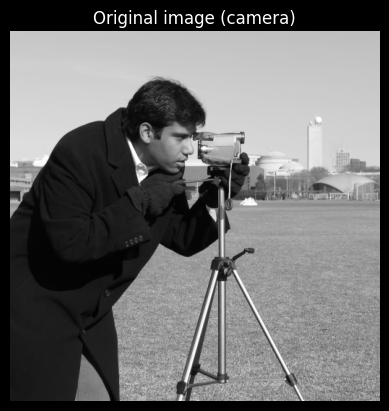

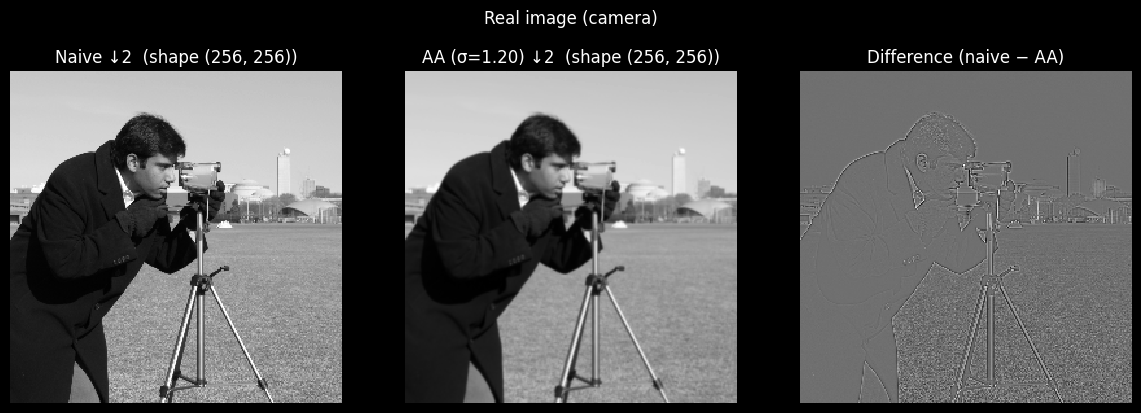

s=2, sigma=1.20 | MAE=0.019562 | MSE=0.001423


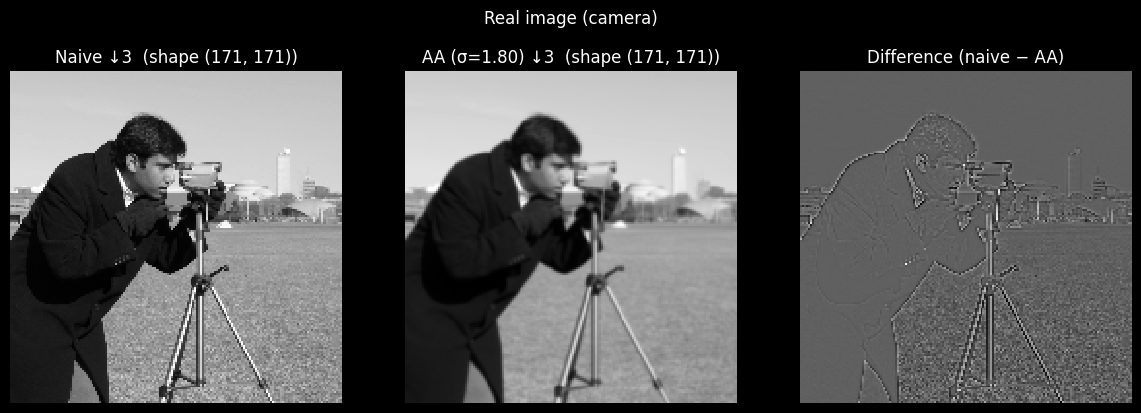

s=3, sigma=1.80 | MAE=0.025059 | MSE=0.002351


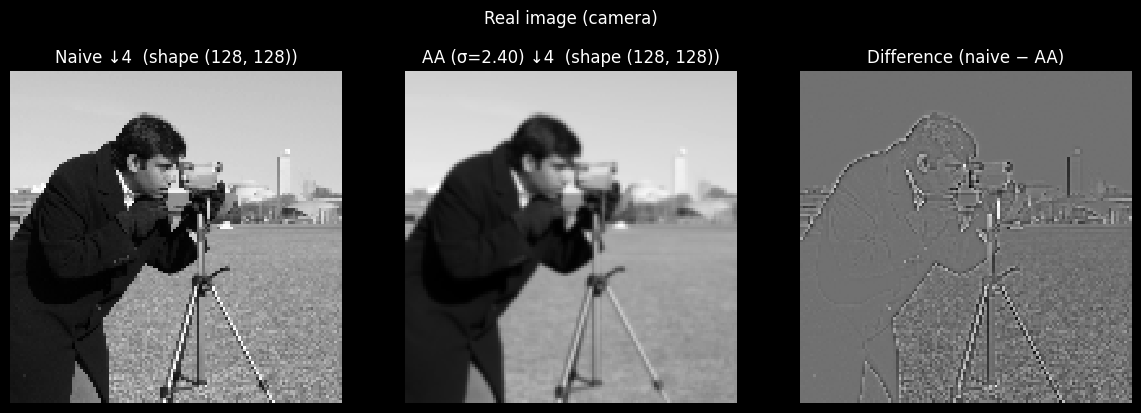

s=4, sigma=2.40 | MAE=0.028475 | MSE=0.003110


In [3]:


# Example: real image
from skimage import data, img_as_float
I = img_as_float(data.camera())[:N, :N]

# plot I
plt.imshow(I, cmap="gray")
plt.title("Original image (camera)")
plt.axis("off")
plt.show()

for s in [2, 3, 4]:
    compare_downsample(I, s, sigma_k=SIGMA_K, suptitle="Real image (camera)")

Downsampled shape: (128, 128)  (same for naive and AA)


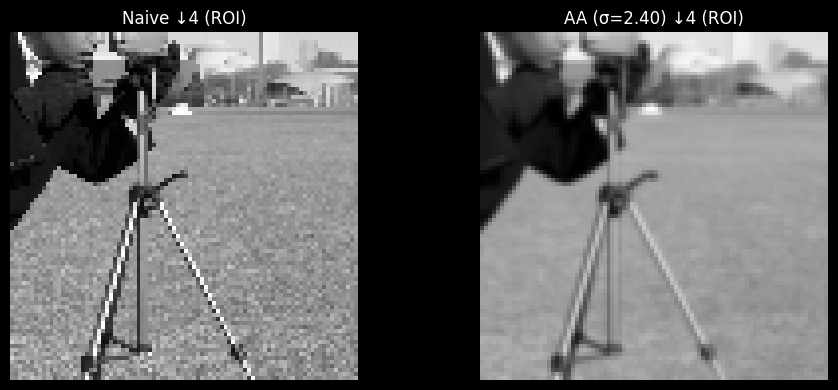

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import data, img_as_float

# ---- input ----
I = img_as_float(data.camera())  # (H,W) in [0,1]

# ---- downsampling setup ----
s = 4
sigma_k = 0.6
sigma = sigma_k * s

In = I[::s, ::s]                              # naive downsample
Ia = gaussian_filter(I, sigma=sigma)[::s, ::s] # low-pass then downsample

print("Downsampled shape:", In.shape, " (same for naive and AA)")

# ---- ROI (IMPORTANT): adjust this to the tripod area in the DOWNSAMPLED image ----
# Tip: start wide, then tighten.
ROI = (slice(40, 170), slice(40, 170))

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(In[ROI], cmap="gray", interpolation="nearest")
axs[0].set_title(f"Naive ↓{s} (ROI)")
axs[0].axis("off")

axs[1].imshow(Ia[ROI], cmap="gray", interpolation="nearest")
axs[1].set_title(f"AA (σ={sigma:.2f}) ↓{s} (ROI)")
axs[1].axis("off")
plt.tight_layout()
plt.show()

# Conclusion on the camera image (what we actually observed)

On the **camera** image, the difference between naive and anti-aliased downsampling becomes clear in regions that contain **fine, repeated texture** and **thin high-contrast structures** (edges, small details).

- With **naive downsampling** (`I[::s, ::s]`), the output can show **stair-stepping (“zigzag”)** on edges and **moiré-like false textures** in detailed areas. These artifacts are not “real details”; they are the visible result of **undersampling**.

- With **anti-aliased downsampling** (Gaussian low-pass **before** decimation), the same areas become **more stable**: the most obvious zigzag/moire artifacts are reduced, but some high-frequency detail is **smoothed**. This blur is the expected cost of removing frequencies that the lower-resolution grid cannot represent.

**Takeaway for the camera image:** when the scene contains fine detail, naive decimation tends to create visually distracting aliasing artifacts, while prefiltering trades a small amount of sharpness for a more faithf